# Step 3 -- composite model test (background + two clouds)

Composes the step-2 PCA background with the existing two-cloud transfer into a
single per-pixel forward model, checks the per-pixel loss and the end-to-end
gradient path, and runs a short **unregularised** smoke-fit on the `t=13` frame.

This is *not* a production inversion: with no regularisation the background/cloud
split is degenerate. Step 3 only delivers the differentiable model + loss; the
regularisation (classical spatial penalties **or** a PINN) is the separate outer
layer chosen later.

In [1]:
import sys
sys.path.insert(0, '..')          # so cloud_model_torch.py / utils.py (repo root) resolve

import numpy as np
import torch
import matplotlib.pyplot as plt

from pca_background import fit_background_basis, PCABackground
from background_model import init_background_coeffs, background
from composite_model import (init_cloud_params, combine_cloud_params,
                             composite_synth, chi2_per_pixel)

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cpu


In [2]:
# ---- configuration --------------------------------------------------
N     = 10                # trailing snapshots that build the basis (step 1)
K     = 6                 # PCA components (step 1)
T     = 13                # fit time step
LAM   = slice(100, 500)   # wavelength crop
YS    = slice(15, -15)    # spatial crop (y)
XS    = slice(15, -15)    # spatial crop (x)

FREEZE_LOGA = False       # log a is a FREE parameter now; set True to freeze it
LOGA_CLAMP  = (-6.0, 0.0) # safe clamp on log a inside the forward (None to disable)

N_ITERS = 400             # short UNREGULARISED smoke-fit (not a production inversion)
LR      = 5e-2

DATA_NPZ  = '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz'


In [3]:
# ---- load cube once; basis block + fit frame; build the step-1 basis
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                             # (t, y, x, lambda)
blk   = np.copy(cube[-N:, YS, XS, LAM]).astype(np.float32)   # -> basis
tofit = np.copy(cube[T,   YS, XS, LAM]).astype(np.float32)   # (Ny, Nx, L) -> fit
del f, cube

Iqs       = float(blk[..., -20:].mean())
tofit_n   = tofit / Iqs
Ny, Nx, L = tofit_n.shape
n_pix     = Ny * Nx

# wavelength axis for the cloud model (numpy; cloud_model_torch casts to float32)
xl = [np.copy(wav[LAM]).astype(np.float32),
      np.asarray([np.mean(wav[LAM])], dtype=np.float32)]

pca = fit_background_basis(blk, n_snapshots=N, n_components=K,
                           wl_slice=None, normalization=Iqs)
print(pca, "| n_pix:", n_pix, "| L:", L)

PCABackground(L=400, K=6, M=150800, cum_var@K=0.9404) | n_pix: 15080 | L: 400


In [4]:
# ---- parameters: 6 background coeffs + 10 cloud (log a free) --------
tofit_pt = torch.from_numpy(tofit_n.reshape(-1, L)).to(device)     # (n_pix, L)
coeffs   = init_background_coeffs(pca, tofit_pt, device=device)    # (n_pix, K)
cparams  = init_cloud_params(n_pix, device=device, freeze_loga=FREEZE_LOGA)

trainable = [coeffs] + [p for p in cparams.values() if p.requires_grad]
free_per_pixel = coeffs.shape[1] + sum(int(p.requires_grad) for p in cparams.values())
print("background coeffs:", tuple(coeffs.shape),
      "| cloud params:", len(cparams),
      "| trainable tensors:", len(trainable),
      "| free per pixel:", free_per_pixel)

background coeffs: (15080, 6) | cloud params: 10 | trainable tensors: 11 | free per pixel: 16


In [5]:
# ---- compose the model and evaluate the per-pixel loss -------------
syn = composite_synth(xl, pca, coeffs, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
chi2, loss = chi2_per_pixel(tofit_pt, syn, reduce_mean=True)
print("syn:", tuple(syn.shape), "| chi2 (per-pixel):", tuple(chi2.shape))
print("initial mean per-pixel chi2:", float(loss),
      "| all finite:", bool(torch.isfinite(syn).all()))

syn: (15080, 400) | chi2 (per-pixel): (15080,)
initial mean per-pixel chi2: 5.181402206420898 | all finite: True


In [6]:
# ---- end-to-end gradient check (both background AND cloud params) --
for p in trainable:
    p.grad = None
_, loss0 = chi2_per_pixel(
    tofit_pt,
    composite_synth(xl, pca, coeffs, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP),
    reduce_mean=True)
loss0.backward()
print("coeffs.grad norm:", float(coeffs.grad.norm()))
for k, p in cparams.items():
    g = None if p.grad is None else round(float(p.grad.norm()), 6)
    print(f"  {k:9s} requires_grad={p.requires_grad}  grad_norm={g}")
print("log a is trained here:", (cparams['c1_loga'].grad is not None) and (not FREEZE_LOGA))

coeffs.grad norm: 0.009097883477807045
  c1_S      requires_grad=True  grad_norm=0.155336
  c1_tau    requires_grad=True  grad_norm=0.003133
  c1_vlos   requires_grad=True  grad_norm=0.002595
  c1_dv     requires_grad=True  grad_norm=0.00344
  c1_loga   requires_grad=True  grad_norm=6e-06
  c2_S      requires_grad=True  grad_norm=0.122744
  c2_tau    requires_grad=True  grad_norm=0.003457
  c2_vlos   requires_grad=True  grad_norm=0.00127
  c2_dv     requires_grad=True  grad_norm=0.00331
  c2_loga   requires_grad=True  grad_norm=0.0
log a is trained here: True


  0%|          | 0/400 [00:00<?, ?it/s]

mean per-pixel chi2: 5.1814e+00 -> 1.1022e-01


Text(0.5, 1.0, 'smoke-fit loss')

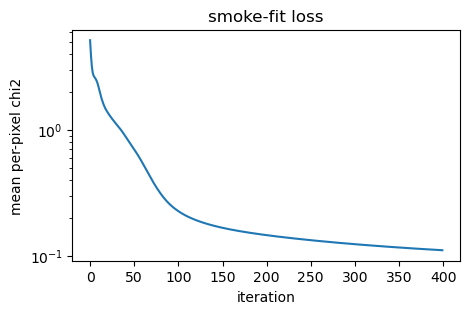

In [7]:
# ---- short UNREGULARISED Adam smoke-fit (differentiability check) ---
from tqdm.auto import trange
opt  = torch.optim.Adam(trainable, lr=LR)
hist = []
for it in trange(N_ITERS):
    opt.zero_grad()
    syn = composite_synth(xl, pca, coeffs, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
    _, loss = chi2_per_pixel(tofit_pt, syn, reduce_mean=True)
    if not torch.isfinite(loss):
        print("non-finite loss at iter", it, "-- stopping"); break
    loss.backward()
    opt.step()
    hist.append(float(loss))
print("mean per-pixel chi2: %.4e -> %.4e" % (hist[0], hist[-1]))
plt.figure(figsize=(5, 3)); plt.semilogy(hist)
plt.xlabel('iteration'); plt.ylabel('mean per-pixel chi2'); plt.title('smoke-fit loss')

Text(0.5, 1.0, 'log10 mean-sq residual  (field mean 2.75e-04)')

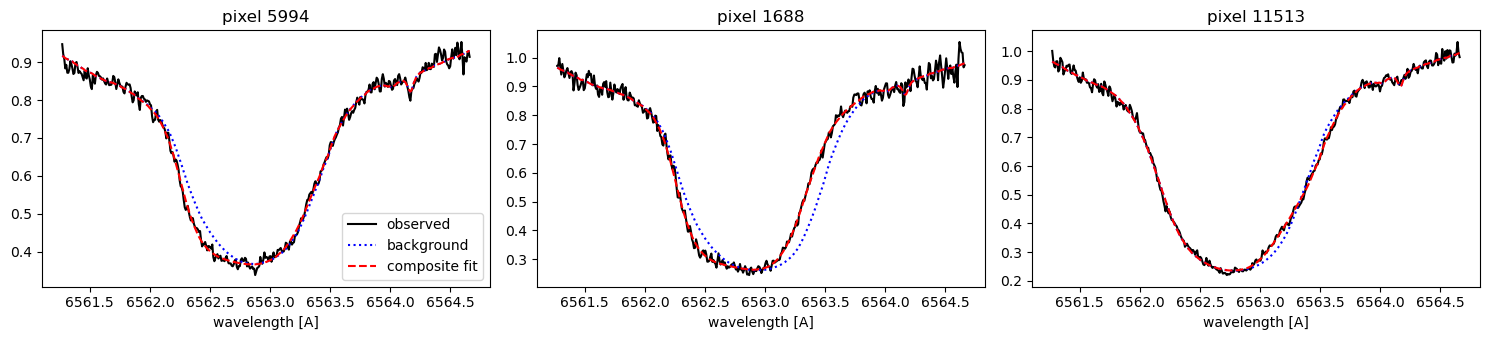

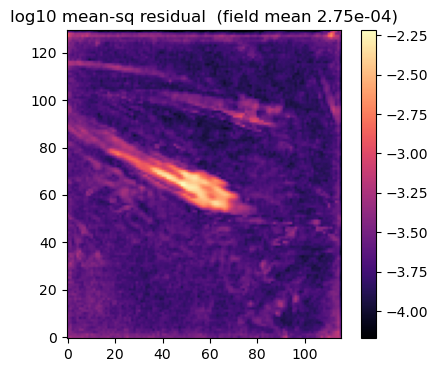

In [8]:
# ---- inspect the fit: data vs composite, plus the background -------
syn    = composite_synth(xl, pca, coeffs, combine_cloud_params(cparams), loga_clamp=LOGA_CLAMP)
syn_np = syn.detach().cpu().numpy()
bkg_np = background(pca, coeffs).detach().cpu().numpy()
wl     = wav[LAM]

np.random.seed(3); idx = np.random.randint(0, n_pix, size=3)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for j, p in enumerate(idx):
    ax[j].plot(wl, tofit_pt[p].cpu().numpy(), 'k',   label='observed')
    ax[j].plot(wl, bkg_np[p],                 'b:',  label='background')
    ax[j].plot(wl, syn_np[p],                 'r--', label='composite fit')
    ax[j].set_title(f'pixel {p}'); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

chi2_map = ((tofit_pt - syn).detach().cpu().numpy() ** 2).sum(-1).reshape(Ny, Nx) / L
plt.figure(figsize=(5, 4))
im = plt.imshow(np.log10(chi2_map).T, origin='lower', cmap='magma'); plt.colorbar(im)
plt.title('log10 mean-sq residual  (field mean %.2e)' % chi2_map.mean())

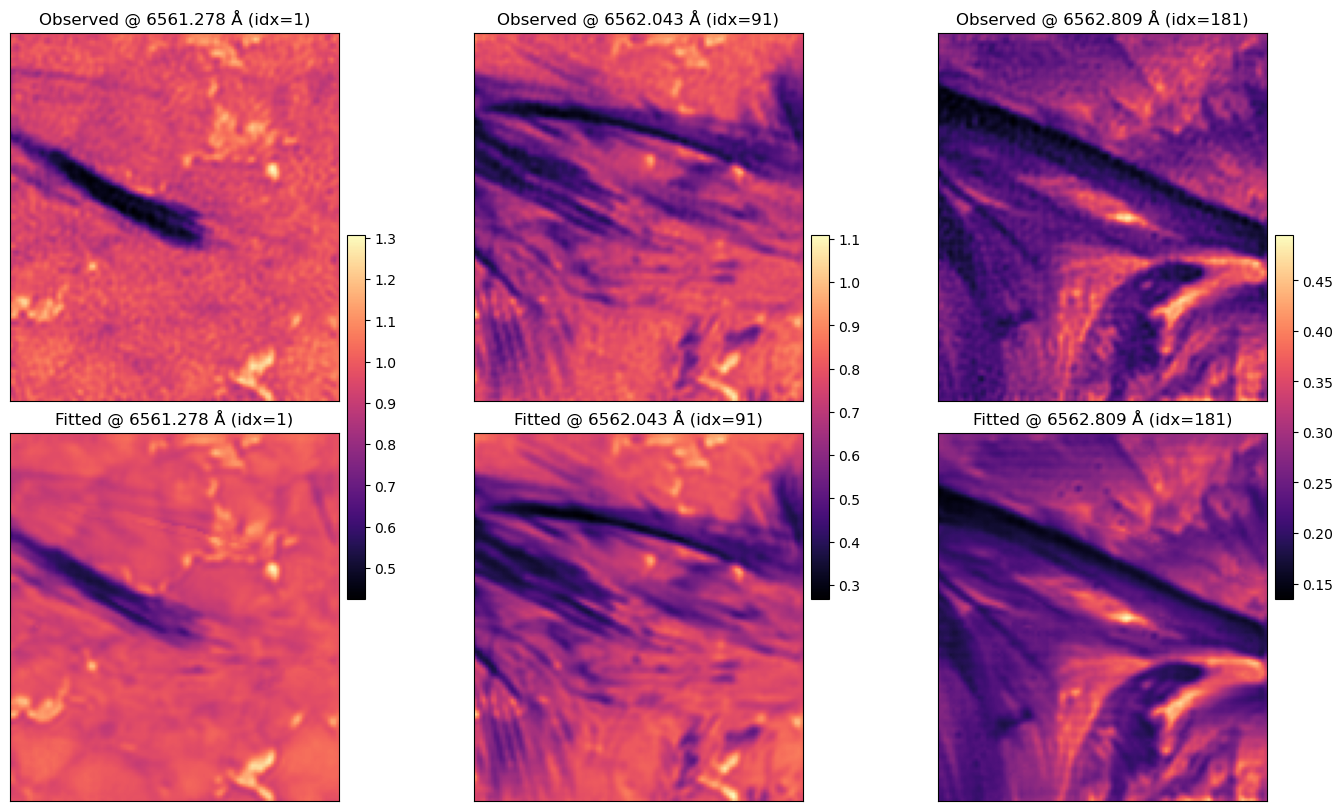

In [ ]:
# 6-panel comparison: observed vs fitted images at three wavelengths

obs_cube = tofit_pt.detach().cpu().numpy().reshape(Ny, Nx, L)
fit_cube = syn.detach().cpu().numpy().reshape(Ny, Nx, L)
core_idx = L // 2  # index of the line core (approx)

# blue wing, line core, red wing (around the existing core_idx)
wl_idxs = np.clip(np.array([core_idx - 180, core_idx-90, core_idx]), 0, L - 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for j, ii in enumerate(wl_idxs):
    obs_img = obs_cube[:, :, ii]
    fit_img = fit_cube[:, :, ii]

    vmin = min(obs_img.min(), fit_img.min())
    vmax = max(obs_img.max(), fit_img.max())

    im_obs = axes[0, j].imshow(obs_img.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, rasterized=True)
    im_fit = axes[1, j].imshow(fit_img.T, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, rasterized=True)

    axes[0, j].set_title(f"Observed @ {wl[ii]:.3f} Å (idx={ii})")
    axes[1, j].set_title(f"Fitted @ {wl[ii]:.3f} Å (idx={ii})")
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

    fig.colorbar(im_fit, ax=[axes[0, j], axes[1, j]], fraction=0.046, pad=0.02)

plt.savefig("../figs/step_3_composite_fit_images.pdf", dpi=300)

## Notes

- The smoke-fit is **unregularised**, so the background/cloud split is degenerate
  (the background can absorb near-rest core absorption). Expected -- step 3 only
  delivers the differentiable per-pixel model + loss. The regularisation that makes
  the inversion well-posed is the **outer layer**: a classical spatially-regularised
  fit (reuse `utils.py` `regu*`) **or** a PINN.
- `log a` is a free parameter here (clamped to `LOGA_CLAMP` for stability); set
  `FREEZE_LOGA = True` to hold it fixed at (-4, -5) as before.